In [3]:
import requests
import pandas as pd

def download_nasa_power_situbondo():
    # Koordinat Situbondo, Jawa Timur
    lat, lon = -7.7081, 114.0044
    url = (
        f"https://power.larc.nasa.gov/api/temporal/climatology/point?"
        f"parameters=ALLSKY_SFC_SW_DWN,T2M&community=RE&"
        f"longitude={lon}&latitude={lat}&format=JSON"
    )

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        irradiance = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
        temperature = data['properties']['parameter']['T2M']

        df = pd.DataFrame({
            'Bulan': list(irradiance.keys())[:-1],
            'GHI_kWh_m2_day': list(irradiance.values())[:-1],
            'Suhu_C': list(temperature.values())[:-1]
        })
        return df
    else:
        raise Exception("Gagal mengunduh data dari NASA POWER")

# Unduh dan tampilkan
df_situbondo = download_nasa_power_situbondo()
print("=== Data Klimatologi Situbondo ===")
print(df_situbondo)

=== Data Klimatologi Situbondo ===
   Bulan  GHI_kWh_m2_day  Suhu_C
0    JAN          5.2709   27.62
1    FEB          5.5111   27.32
2    MAR          5.6371   27.72
3    APR          5.5231   28.25
4    MAY          5.2291   28.20
5    JUN          5.0834   27.63
6    JUL          5.4010   27.20
7    AUG          6.0698   27.37
8    SEP          6.6175   28.33
9    OCT          6.6403   29.23
10   NOV          6.0962   29.32
11   DEC          5.1187   28.23


In [4]:
import requests
import pandas as pd

def download_nasa_power_situbondo_dengan_metadata():
    lat, lon = -7.7081, 114.0044
    url = (
        f"https://power.larc.nasa.gov/api/temporal/climatology/point?"
        f"parameters=ALLSKY_SFC_SW_DWN,T2M&community=RE&"
        f"longitude={lon}&latitude={lat}&format=JSON"
    )

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()

        # EKSTRAKSI METADATA RENTANG TAHUN DARI NASA
        # NASA biasanya menyimpan info rentang data di dalam list 'messages'
        pesan_api = data.get('messages', [])
        rentang_waktu = "Rentang Waktu Historis NASA POWER"
        for msg in pesan_api:
            if "climatology" in msg.lower() or "based on" in msg.lower():
                rentang_waktu = msg
                break

        irradiance = data['properties']['parameter']['ALLSKY_SFC_SW_DWN']
        temperature = data['properties']['parameter']['T2M']

        df = pd.DataFrame({
            'Bulan': list(irradiance.keys())[:-1],
            'GHI_kWh_m2_day': list(irradiance.values())[:-1],
            'Suhu_C': list(temperature.values())[:-1]
        })
        return df, rentang_waktu
    else:
        raise Exception("Gagal mengunduh data dari NASA POWER")

# Unduh data dan simpan informasi rentang waktunya
df_situbondo, info_rentang = download_nasa_power_situbondo_dengan_metadata()

print("=== Data Klimatologi Situbondo ===")
print(df_situbondo.head())
print("\n=== Informasi Rentang Tahun Data (Metadata NASA) ===")
print(info_rentang)

=== Data Klimatologi Situbondo ===
  Bulan  GHI_kWh_m2_day  Suhu_C
0   JAN          5.2709   27.62
1   FEB          5.5111   27.32
2   MAR          5.6371   27.72
3   APR          5.5231   28.25
4   MAY          5.2291   28.20

=== Informasi Rentang Tahun Data (Metadata NASA) ===
Rentang Waktu Historis NASA POWER


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# ASUMSI TEKNO-EKONOMI (Berdasarkan Literatur)
# ==========================================
P_capacity_MW = 10         # Kapasitas 10 MWp
PR = 0.78                  # Performance Ratio 78% (losses 22%)
CAPEX_per_MW = 700000      # USD 700,000 / MWp (Data IRENA)
OPEX_percent = 0.015       # OPEX 1.5% dari CAPEX per tahun (NREL)
discount_rate = 0.08       # WACC 8%
umur_proyek = 25           # Umur ekonomis 25 tahun
degradasi = 0.005          # Degradasi panel 0.5% per tahun

# ==========================================
# PERHITUNGAN ANALISIS
# ==========================================
# 1. Hitung rata-rata GHI tahunan
avg_ghi = df_situbondo['GHI_kWh_m2_day'].astype(float).mean()

# 2. Produksi Energi Tahun Pertama (MWh)
E_year1 = P_capacity_MW * avg_ghi * PR * 365

# 3. Capacity Factor
CF = (E_year1 / (P_capacity_MW * 8760)) * 100

# 4. Perhitungan LCOE
CAPEX = P_capacity_MW * CAPEX_per_MW
OPEX = CAPEX * OPEX_percent

pv_costs = CAPEX
pv_energy = 0

for t in range(1, umur_proyek + 1):
    pv_costs += OPEX / ((1 + discount_rate) ** t)
    # Energi menurun setiap tahun karena degradasi
    energi_t = E_year1 * ((1 - degradasi) ** (t - 1))
    pv_energy += energi_t / ((1 + discount_rate) ** t)

LCOE_USD_MWh = pv_costs / pv_energy
LCOE_Cent_kWh = LCOE_USD_MWh / 10

# Cetak Hasil untuk Bab IV
print("\n=== Hasil Analisis Tekno-Ekonomi PLTS Situbondo ===")
print(f"Rata-rata GHI       : {avg_ghi:.2f} kWh/m2/hari")
print(f"Produksi Thn ke-1   : {E_year1:.2f} MWh")
print(f"Capacity Factor     : {CF:.2f} %")
print(f"LCOE                : {LCOE_Cent_kWh:.2f} Cent USD/kWh")

# ==========================================
# VISUALISASI DATA (SIAP UNTUK PAPER IEEE)
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

# GRAFIK 1: Profil Irradiasi dan Suhu Sepanjang Tahun
fig, ax1 = plt.subplots(figsize=(8, 4.5))

bulan_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_situbondo['Bulan'] = pd.Categorical(df_situbondo['Bulan'], categories=bulan_order, ordered=True)
df_situbondo['GHI_kWh_m2_day'] = df_situbondo['GHI_kWh_m2_day'].astype(float)
df_situbondo['Suhu_C'] = df_situbondo['Suhu_C'].astype(float)

color_ghi = 'tab:orange'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('GHI (kWh/m²/hari)', color=color_ghi, fontweight='bold')
sns.barplot(data=df_situbondo, x='Bulan', y='GHI_kWh_m2_day', color=color_ghi, alpha=0.8, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color_ghi)

ax2 = ax1.twinx()
color_suhu = 'tab:blue'
ax2.set_ylabel('Suhu Permukaan (°C)', color=color_suhu, fontweight='bold')
sns.lineplot(data=df_situbondo, x='Bulan', y='Suhu_C', color=color_suhu, marker='o', linewidth=2.5, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color_suhu)
# Batasi skala agar garis suhu terlihat jelas di atas bar
ax2.set_ylim(df_situbondo['Suhu_C'].min() - 2, df_situbondo['Suhu_C'].max() + 2)

plt.title('Profil Irradiasi Matahari dan Suhu Bulanan di Situbondo', pad=15, fontweight='bold')
plt.tight_layout()
plt.savefig('grafik_situbondo_profil.png', dpi=300, bbox_inches='tight')
plt.close()

# GRAFIK 2: Proyeksi Produksi Energi Selama 25 Tahun (Degradasi)
tahun = np.arange(1, umur_proyek + 1)
produksi_tahunan = [E_year1 * ((1 - degradasi) ** (t - 1)) for t in tahun]

plt.figure(figsize=(8, 4))
sns.lineplot(x=tahun, y=produksi_tahunan, color='tab:green', linewidth=2.5)
plt.fill_between(tahun, produksi_tahunan, color='tab:green', alpha=0.2)

plt.title('Proyeksi Produksi Energi PLTS 10 MWp (Efek Degradasi 0.5%/thn)', pad=15, fontweight='bold')
plt.xlabel('Tahun Operasional')
plt.ylabel('Produksi Energi (MWh)')
plt.xlim(1, 25)
plt.ylim(0, max(produksi_tahunan) * 1.1)

plt.tight_layout()
plt.savefig('grafik_situbondo_degradasi.png', dpi=300, bbox_inches='tight')
plt.close()

print("\nGrafik berhasil disimpan sebagai 'grafik_situbondo_profil.png' dan 'grafik_situbondo_degradasi.png'.")


=== Hasil Analisis Tekno-Ekonomi PLTS Situbondo ===
Rata-rata GHI       : 5.68 kWh/m2/hari
Produksi Thn ke-1   : 16180.02 MWh
Capacity Factor     : 18.47 %
LCOE                : 4.90 Cent USD/kWh

Grafik berhasil disimpan sebagai 'grafik_situbondo_profil.png' dan 'grafik_situbondo_degradasi.png'.


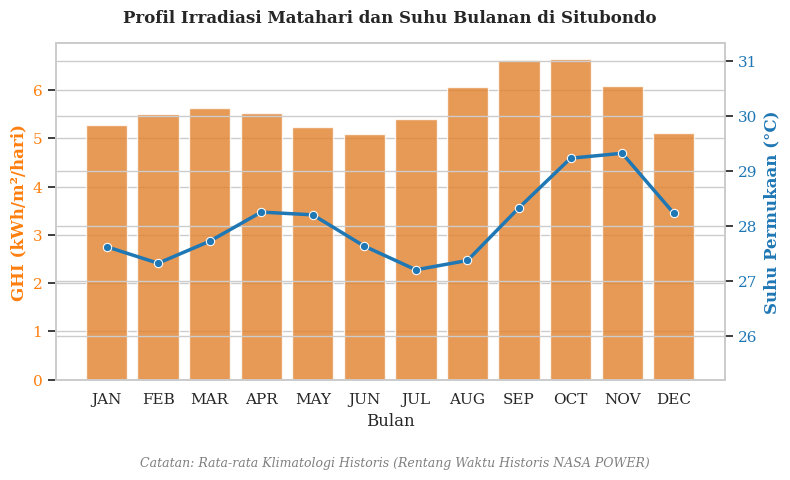

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'font.family': 'serif'})

fig, ax1 = plt.subplots(figsize=(8, 4.5))

bulan_order = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']
df_situbondo['Bulan'] = pd.Categorical(df_situbondo['Bulan'], categories=bulan_order, ordered=True)
df_situbondo['GHI_kWh_m2_day'] = df_situbondo['GHI_kWh_m2_day'].astype(float)
df_situbondo['Suhu_C'] = df_situbondo['Suhu_C'].astype(float)

# Plot Irradiasi (Bar)
color_ghi = 'tab:orange'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('GHI (kWh/m²/hari)', color=color_ghi, fontweight='bold')
sns.barplot(data=df_situbondo, x='Bulan', y='GHI_kWh_m2_day', color=color_ghi, alpha=0.8, ax=ax1)
ax1.tick_params(axis='y', labelcolor=color_ghi)

# Plot Suhu (Line)
ax2 = ax1.twinx()
color_suhu = 'tab:blue'
ax2.set_ylabel('Suhu Permukaan (°C)', color=color_suhu, fontweight='bold')
sns.lineplot(data=df_situbondo, x='Bulan', y='Suhu_C', color=color_suhu, marker='o', linewidth=2.5, ax=ax2)
ax2.tick_params(axis='y', labelcolor=color_suhu)
ax2.set_ylim(df_situbondo['Suhu_C'].min() - 2, df_situbondo['Suhu_C'].max() + 2)

plt.title('Profil Irradiasi Matahari dan Suhu Bulanan di Situbondo', pad=15, fontweight='bold')

# === TAMBAHAN VISUALISASI RENTANG TAHUN ===
# Ini akan mencetak metadata dari NASA tepat di bawah sumbu X
plt.figtext(0.5, -0.05, f"Catatan: Rata-rata Klimatologi Historis ({info_rentang})",
            ha="center", fontsize=9, color="gray", style='italic')

plt.tight_layout()
# Tambahkan bbox_inches agar teks di bawah tidak terpotong saat disimpan
plt.savefig('grafik_situbondo_dengan_rentang_tahun.png', dpi=300, bbox_inches='tight')
plt.show()

    Skenario  LCOE (Cent USD/kWh)
0    Optimis             3.527406
1  Base Case             4.899782
2    Pesimis             7.099523


/tmp/ipykernel_1315/508366887.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_hasil, x='Skenario', y='LCOE (Cent USD/kWh)', palette=colors, width=0.6)



Grafik berhasil disimpan sebagai 'grafik_sensitivitas_lcoe.png'


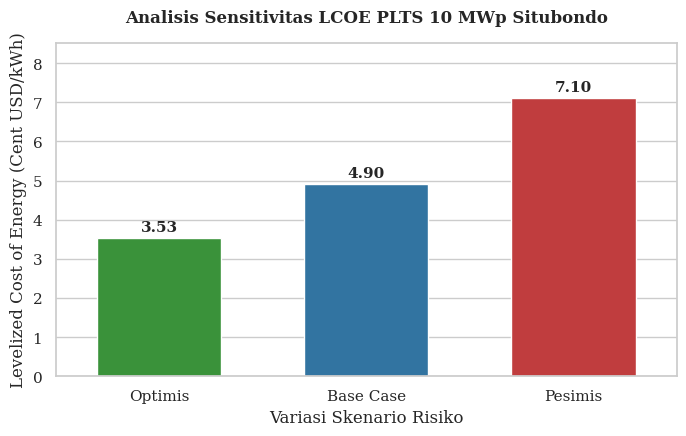

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# FUNGSI PERHITUNGAN LCOE DINAMIS
# ==========================================
def hitung_lcoe_skenario(capex_per_mw, wacc, pr_value):
    P_capacity_MW = 10
    avg_ghi_10thn = 5.68  # Masukkan angka rata-rata GHI NASA Anda di sini (misal 5.65)
    umur_proyek = 25
    degradasi = 0.005
    OPEX_percent = 0.015

    E_year1 = P_capacity_MW * avg_ghi_10thn * pr_value * 365
    CAPEX = P_capacity_MW * capex_per_mw
    OPEX = CAPEX * OPEX_percent

    pv_costs = CAPEX
    pv_energy = 0

    for t in range(1, umur_proyek + 1):
        pv_costs += OPEX / ((1 + wacc) ** t)
        energi_t = E_year1 * ((1 - degradasi) ** (t - 1))
        pv_energy += energi_t / ((1 + wacc) ** t)

    return (pv_costs / pv_energy) / 10  # Konversi ke Cent USD/kWh

# ==========================================
# DEFINISI 3 SKENARIO
# ==========================================
skenario_data = {
    'Optimis': {'CAPEX': 600000, 'WACC': 0.06, 'PR': 0.80},
    'Base Case': {'CAPEX': 700000, 'WACC': 0.08, 'PR': 0.78},
    'Pesimis': {'CAPEX': 850000, 'WACC': 0.10, 'PR': 0.75}
}

hasil_lcoe = []
for nama, s in skenario_data.items():
    lcoe_val = hitung_lcoe_skenario(s['CAPEX'], s['WACC'], s['PR'])
    hasil_lcoe.append({'Skenario': nama, 'LCOE (Cent USD/kWh)': lcoe_val})

df_hasil = pd.DataFrame(hasil_lcoe)
print(df_hasil)

# ==========================================
# VISUALISASI GRAFIK JURNAL
# ==========================================
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

plt.figure(figsize=(7, 4.5))

# Tentukan warna kontras untuk masing-masing skenario
colors = ['#2ca02c', '#1f77b4', '#d62728']

ax = sns.barplot(data=df_hasil, x='Skenario', y='LCOE (Cent USD/kWh)', palette=colors, width=0.6)

# Tambahkan label angka persis di atas bar
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 8),
                textcoords = 'offset points',
                fontweight='bold')

plt.title('Analisis Sensitivitas LCOE PLTS 10 MWp Situbondo', pad=15, fontweight='bold')
plt.ylabel('Levelized Cost of Energy (Cent USD/kWh)')
plt.xlabel('Variasi Skenario Risiko')
plt.ylim(0, df_hasil['LCOE (Cent USD/kWh)'].max() * 1.2)

plt.tight_layout()
plt.savefig('grafik_sensitivitas_lcoe.png', dpi=300)
print("\nGrafik berhasil disimpan sebagai 'grafik_sensitivitas_lcoe.png'")
plt.show()